# 02 - Blur Detection and Removal

## Why Blur Matters in Histopathology

Whole slide images (WSIs) often contain **out-of-focus areas** caused by:
- Tissue folds absorbing light differently
- Scanner focus issues
- Specimen preparation artifacts

The paper (Section 3.3) shows that blur artifacts cause:
- **False positive segmentation** (blurred tissue folds detected as nuclei)
- **Failed automatic threshold selection**
- Up to **25% worse AJI** and **21.5% worse Dice** without blur removal

**Methods compared:**
1. **Laplacian Variance** (simple baseline)
2. **DCT-based HiFST** (paper's method - Spatially Varying Blur Detection)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.filters import gaussian

from src.utils.data_loader import load_dataset
from src.utils.visualization import show_blur_detection
from src.preprocessing.blur_detection import (
    detect_blur, remove_blur_artifacts, compute_blur_score,
    laplacian_variance_blur_map
)

plt.rcParams['figure.dpi'] = 100
DATA_ROOT = '../../data'

# Load a few images
images, masks, names = load_dataset(DATA_ROOT, 'monuseg', max_images=4)
print(f'Loaded {len(images)} images')

Loaded 4 images


## 1. Understanding Blur in Histopathology

Let's first create synthetic blurred versions to demonstrate the concept.

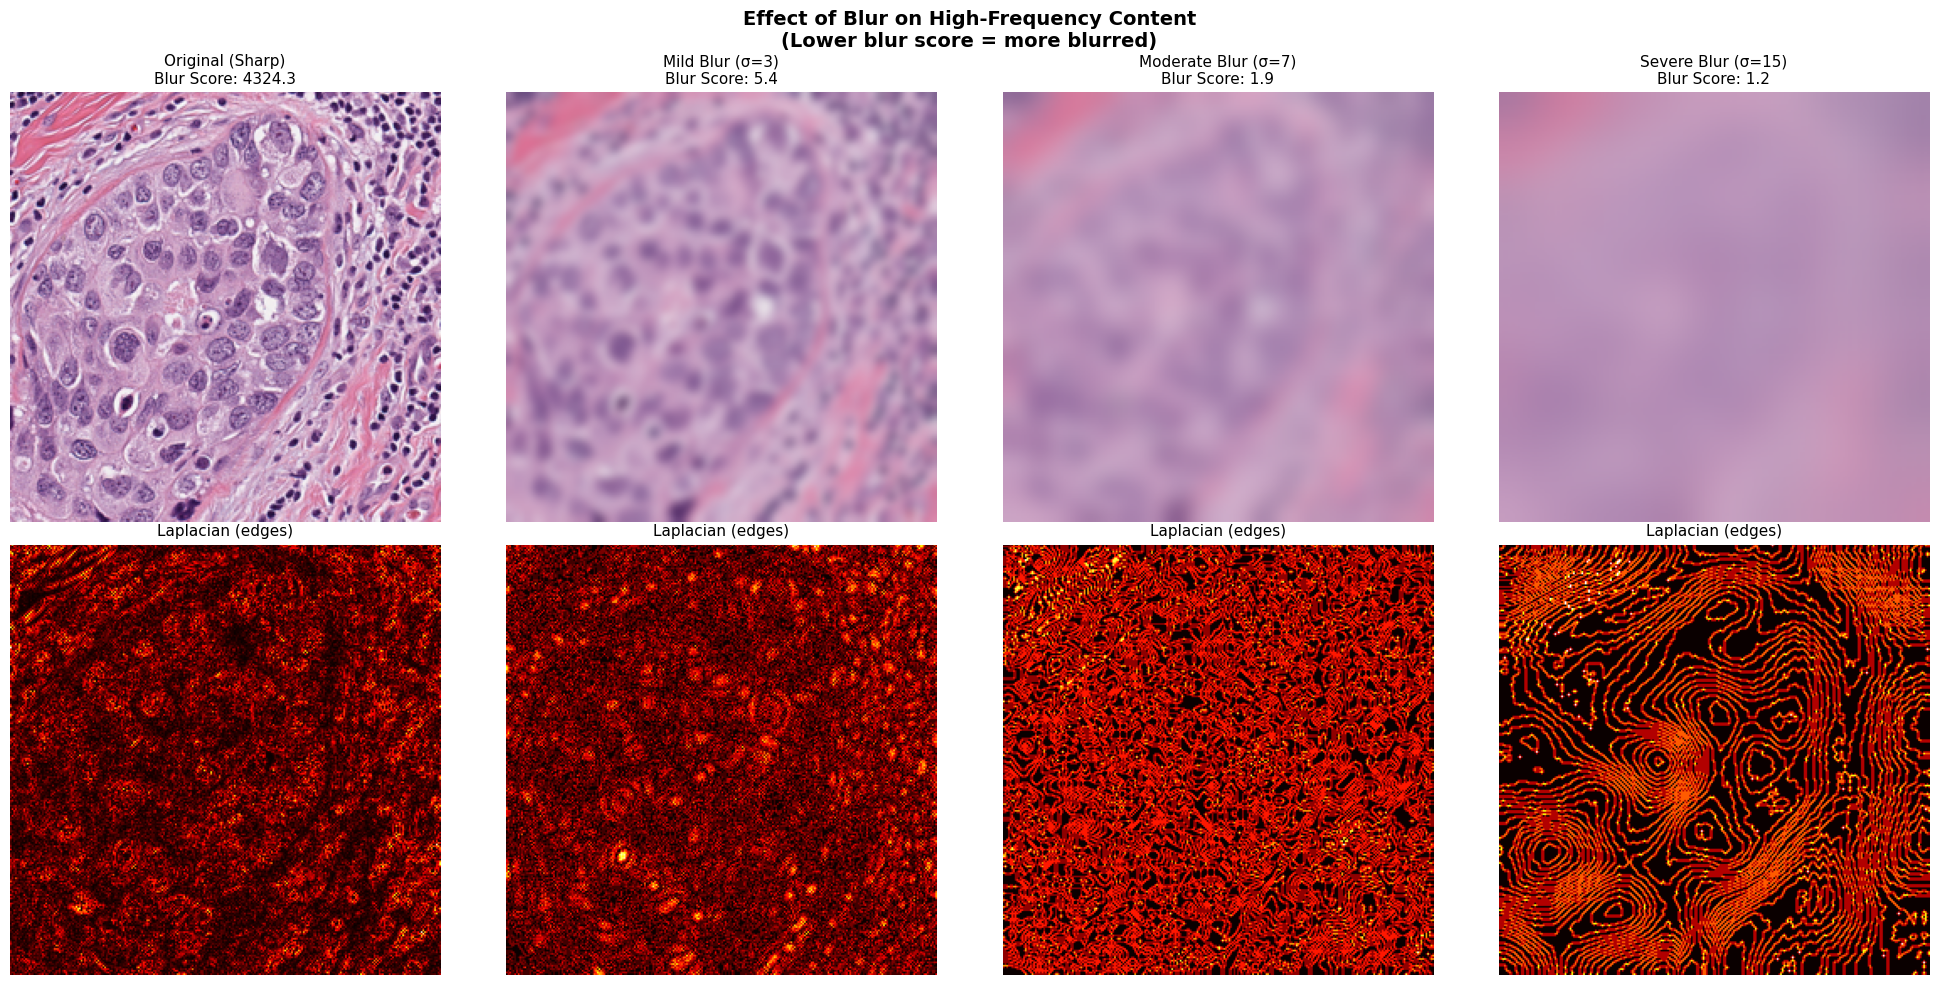

Key insight: Blur removes high-frequency edges that are crucial for nuclei detection.
The Laplacian operator highlights edges - notice how they fade with increasing blur.


In [2]:
# Demonstrate blur effect
img = images[0]

# Create versions with different blur levels
blur_levels = {
    'Original (Sharp)': img,
    'Mild Blur (σ=3)': cv2.GaussianBlur(img, (0, 0), 3),
    'Moderate Blur (σ=7)': cv2.GaussianBlur(img, (0, 0), 7),
    'Severe Blur (σ=15)': cv2.GaussianBlur(img, (0, 0), 15),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (title, blurred) in enumerate(blur_levels.items()):
    axes[0, i].imshow(blurred)
    score = compute_blur_score(blurred)
    axes[0, i].set_title(f'{title}\nBlur Score: {score:.1f}', fontsize=11)
    axes[0, i].axis('off')
    
    # Show Laplacian (high-frequency content)
    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    laplacian = np.abs(cv2.Laplacian(gray, cv2.CV_64F))
    axes[1, i].imshow(laplacian, cmap='hot')
    axes[1, i].set_title('Laplacian (edges)', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle('Effect of Blur on High-Frequency Content\n(Lower blur score = more blurred)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: Blur removes high-frequency edges that are crucial for nuclei detection.")
print("The Laplacian operator highlights edges - notice how they fade with increasing blur.")

## 2. Simulate Spatially Varying Blur

In real WSIs, blur doesn't affect the entire image uniformly.
Some regions are in focus while others aren't.

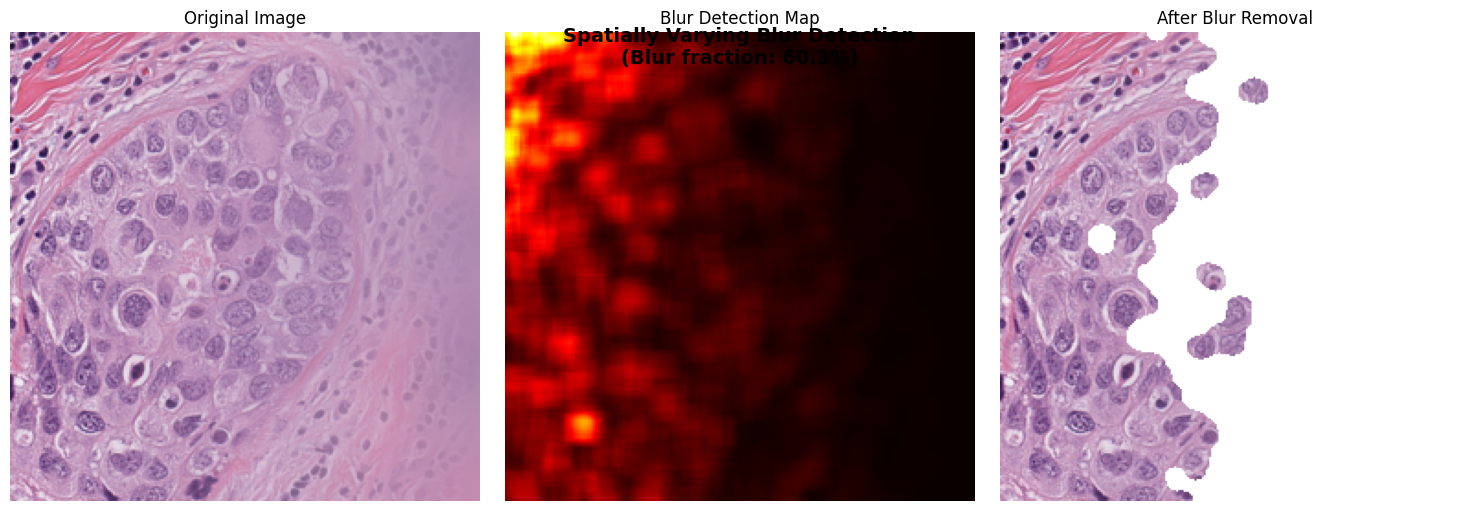


Blurred area detected: 60.3% of the image
The blur map correctly identifies the right side as blurred (darker in map).


In [3]:
# Create an image with spatially varying blur (simulating a real WSI artifact)
img = images[0].copy()
h, w = img.shape[:2]

# Create a gradient blur: left side sharp, right side blurred
blurred_img = cv2.GaussianBlur(img, (0, 0), 15)
alpha = np.linspace(0, 1, w).reshape(1, -1, 1)
alpha = np.tile(alpha, (h, 1, 3))
mixed = (img * (1 - alpha) + blurred_img * alpha).astype(np.uint8)

# Detect blur
blur_map, blur_mask = detect_blur(mixed, method='laplacian', threshold=0.1)
clean_img, blur_fraction = remove_blur_artifacts(mixed, blur_mask)

fig = show_blur_detection(mixed, blur_map, clean_img)
plt.suptitle(f'Spatially Varying Blur Detection\n(Blur fraction: {blur_fraction:.1%})', 
             fontsize=14, fontweight='bold')
plt.show()

print(f"\nBlurred area detected: {blur_fraction:.1%} of the image")
print("The blur map correctly identifies the right side as blurred (darker in map).")

## 3. Impact of Blur on Segmentation

Let's demonstrate why blur removal matters for nuclei segmentation.

C:\Users\ASUS\Desktop\nuclei-segmentation-pipeline\gastric_nuclei_poc\notebooks\..\src\segmentation\otsu_watershed.py:122: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_holes(binary, area_threshold=params["hole_area"])
C:\Users\ASUS\Desktop\nuclei-segmentation-pipeline\gastric_nuclei_poc\notebooks\..\src\segmentation\otsu_watershed.py:123: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes object

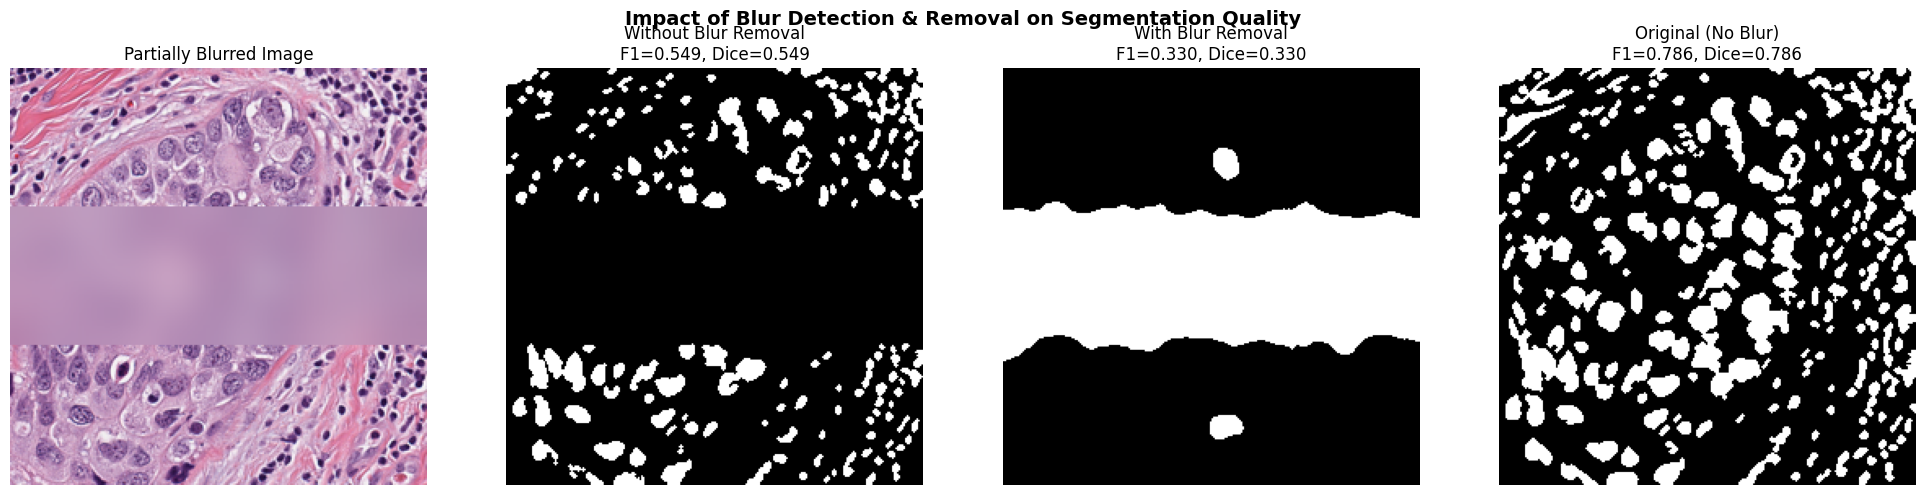

In [4]:
from src.segmentation.otsu_watershed import segment_otsu_watershed
from src.evaluation.metrics import compute_all_metrics

img = images[0]
gt_mask = masks[0]

# Create a partially blurred version
blurred_img = img.copy()
blurred_img[h//3:2*h//3, :] = cv2.GaussianBlur(img[h//3:2*h//3, :], (0, 0), 12)

# Segment without blur removal
seg_no_blur_removal, _ = segment_otsu_watershed(blurred_img)

# Segment with blur removal
blur_map, blur_mask = detect_blur(blurred_img, method='laplacian', threshold=0.1)
clean, _ = remove_blur_artifacts(blurred_img, blur_mask)
seg_with_blur_removal, _ = segment_otsu_watershed(clean)

# Segment original (reference)
seg_original, _ = segment_otsu_watershed(img)

# Compare metrics
metrics_no_removal = compute_all_metrics(gt_mask, seg_no_blur_removal)
metrics_with_removal = compute_all_metrics(gt_mask, seg_with_blur_removal)
metrics_original = compute_all_metrics(gt_mask, seg_original)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(blurred_img)
axes[0].set_title('Partially Blurred Image')
axes[0].axis('off')

axes[1].imshow(seg_no_blur_removal, cmap='gray')
axes[1].set_title(f'Without Blur Removal\nF1={metrics_no_removal["F1"]:.3f}, Dice={metrics_no_removal["Dice"]:.3f}')
axes[1].axis('off')

axes[2].imshow(seg_with_blur_removal, cmap='gray')
axes[2].set_title(f'With Blur Removal\nF1={metrics_with_removal["F1"]:.3f}, Dice={metrics_with_removal["Dice"]:.3f}')
axes[2].axis('off')

axes[3].imshow(seg_original, cmap='gray')
axes[3].set_title(f'Original (No Blur)\nF1={metrics_original["F1"]:.3f}, Dice={metrics_original["Dice"]:.3f}')
axes[3].axis('off')

plt.suptitle('Impact of Blur Detection & Removal on Segmentation Quality', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Blur Scores Across the Dataset

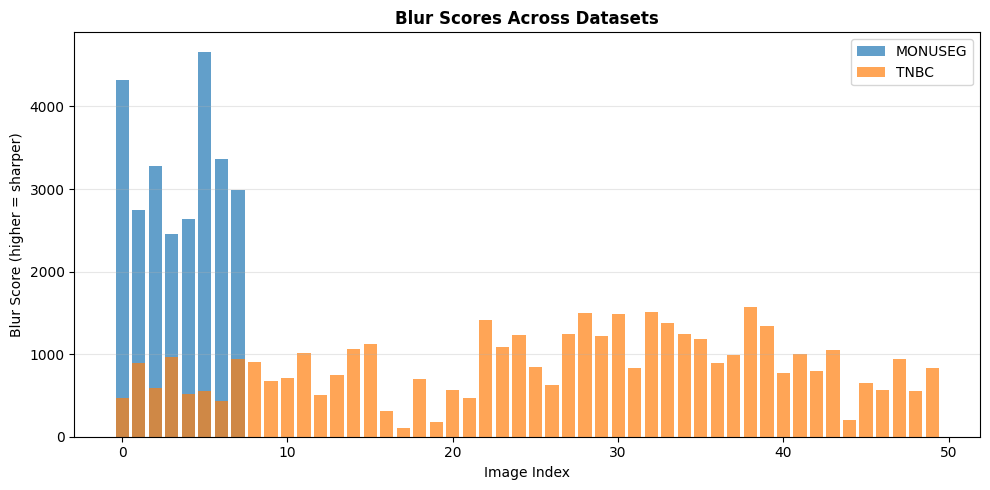


Summary:
         count    mean    std     min     25%     50%     75%     max
Dataset                                                              
MONUSEG    8.0  3307.6  800.2  2450.4  2716.1  3137.8  3605.9  4664.5
TNBC      50.0   867.5  368.2   109.6   568.4   863.1  1113.5  1574.4


In [5]:
# Compute blur scores for all images
all_scores = []
for ds_name in ['monuseg', 'tnbc']:
    try:
        imgs, _, img_names = load_dataset(DATA_ROOT, ds_name)
        for img, name in zip(imgs, img_names):
            score = compute_blur_score(img)
            all_scores.append({'Dataset': ds_name.upper(), 'Image': name, 'Blur Score': score})
    except FileNotFoundError:
        pass

import pandas as pd
df_blur = pd.DataFrame(all_scores)

fig, ax = plt.subplots(figsize=(10, 5))
for ds in df_blur['Dataset'].unique():
    subset = df_blur[df_blur['Dataset'] == ds]
    ax.bar(range(len(subset)), subset['Blur Score'], label=ds, alpha=0.7)

ax.set_xlabel('Image Index')
ax.set_ylabel('Blur Score (higher = sharper)')
ax.set_title('Blur Scores Across Datasets', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary:")
print(df_blur.groupby('Dataset')['Blur Score'].describe().round(1))

## Summary

**Key takeaways from the paper:**
- Blur artifacts are common in WSIs and significantly degrade segmentation quality
- The paper achieved **up to 25% AJI improvement** with blur removal (Table 1)
- The HiFST method detects blur without prior knowledge of blur type or scanner
- Blur removal should be the **first preprocessing step** before any normalization or segmentation